In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from models.position_embedding import SinusoidalPositionEmbeddings
from models.unet import UNet
from utils import visualise_loader, make_beta_schedule, periodic_sample_grids, ancestral_sample, plot_ancestral_samples, plot_sampling_norms
from diffusion.diffusion import DiffusionProcess


In [2]:
EPOCHS = 50
L = 1000
BATCH = 128

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [3]:
# Loading MNIST dataset
# Convert to tensor and normalize between -1 and 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH, shuffle=True, num_workers=4)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH, shuffle=False, num_workers=4)
    

# Schedule Ablation

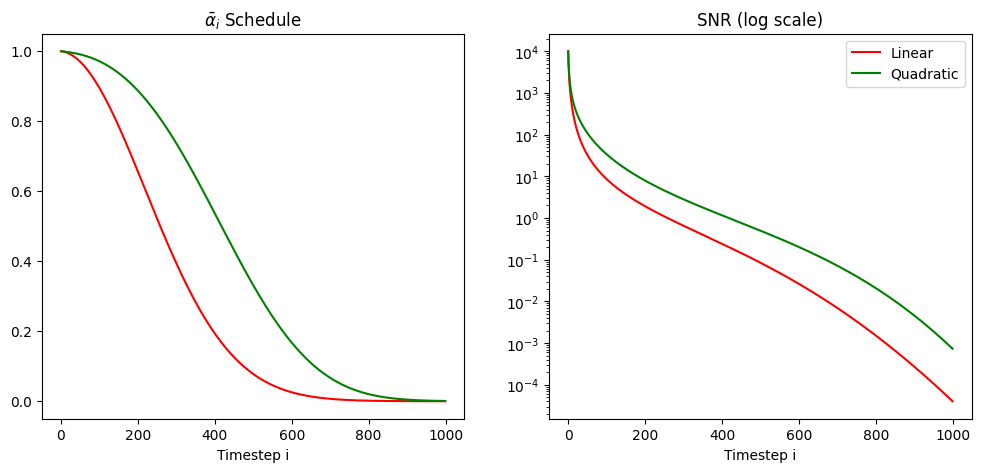

In [5]:
lin_diff = DiffusionProcess(L=1000, device=device)
lin_alphas_bar = lin_diff.alphas_cumprod.to("cpu").numpy()
lin_snr = lin_alphas_bar / (1 - lin_alphas_bar)

quad_diff = DiffusionProcess(L=1000, device=device, beta_schedule_type="quadratic")
quad_alphas_bar = quad_diff.alphas_cumprod.to("cpu").numpy()
quad_snr = quad_alphas_bar / (1 - quad_alphas_bar)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lin_alphas_bar, "r", label="Linear")
plt.plot(quad_alphas_bar, "g", label="Quadratic")
plt.title(r"$\bar{\alpha}_i$ Schedule")
plt.xlabel("Timestep i")

plt.subplot(1, 2, 2)
plt.plot(lin_snr, "r", label="Linear")
plt.plot(quad_snr, "g", label="Quadratic")
plt.yscale('log')
plt.title("SNR (log scale)")
plt.xlabel("Timestep i")
plt.legend()
plt.show()

In [ ]:
model = UNet()
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.MSELoss()

In [ ]:
losses = []
val_imgs, _ = next(iter(test_loader))
model.to(device)
for i in tqdm(range(EPOCHS)):
    acc_loss = 0
    for img, _ in train_loader:
        img = img.to(device)
        start = quad_diff.sample_timesteps(img.shape[0]).to(device)
        eps = torch.randn_like(img, device=device)
        xi = quad_diff.q_sample(img, start, eps)

        eps_hat = model(xi, start)

        loss = criterion(eps_hat, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc_loss += loss.item()
    losses.append(acc_loss)

    if i % 5 == 0:
        total_norm = sum(p.grad.detach().data.norm(2).item() ** 2 for p in model.parameters() if p.grad is not None) ** 0.5
        corr = check_noise_correlation(model, quad_diff, val_imgs.to(device))
        print(f"\nEpoch {i+1} | Loss = {acc_loss} | Grad Norm: {total_norm:.4f} | Noise Corr: {corr:.4f}")
        periodic_sample_grids(model, 9, device)

plt.title("Loss Curve")
plt.plot(losses, np.arange(1,EPOCHS+1))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

torch.save(model.state_dict(), "quad_model_weights.pth")
print("Model saved successfully!")
np.save("quad_losses.npy", np.array(losses))
print("Losses saved successfully!")

In [ ]:
final_xi, intermediates, norms = ancestral_sample(model, diff, count=5, device=device)
plot_ancestral_samples(intermediates, count=5)
plot_sampling_norms(norms, L=diff.L)